## How to Build a Global Inflation Dashboard in Python (Data Visualization Tutorial)
#### [Click here to view full article](https://developers.lseg.com/en/article-catalog/article/global-inflation-dashboard-python)

In [1]:
# Step 1: Import libraries and connect to DataStream
import DatastreamPy as dsws
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

ds=dsws.DataClient(username='YOUR_USERNAME',password='YOUR_PASSWORD')

In [2]:
# Step 2: Define Countries
series = [
    "USCPANNL",  # United States
    "UKCPANNL",  # United Kingdom
    "JPCPANNL",  # Japan
    "FRCPANNL",  # France
    "ITCPANNL",  # Italy
    "DECPANNL",  # Germany
    "CNCPANNL",  # Canada
    "IDCPANNL",  # Indonesia
    "INCPANNL",  # India
    "NZCPANNL"   # New Zealand
]

tickers_input = ",".join(series)
tickers_input

'USCPANNL,UKCPANNL,JPCPANNL,FRCPANNL,ITCPANNL,DECPANNL,CNCPANNL,IDCPANNL,INCPANNL,NZCPANNL'

In [3]:
# Step 3: Fetch Data
data = ds.get_data(
    tickers=tickers_input,
    start="2020-01-01",
    end="2026-01-01",
    freq="M"
)
data.head()

Instrument,USCPANNL,UKCPANNL,JPCPANNL,FRCPANNL,ITCPANNL,CNCPANNL,IDCPANNL,INCPANNL,NZCPANNL
Field,,,,,,,,,
Currency,NA,NA,NA,TL,NA,TL,NA,NA,NA
Dates,,,,,,,,,
2020-01-15,2.49,1.8,0.8,1.49,0.48,2.40,2.68,7.62,2.5
2020-02-15,2.33,1.7,0.6,1.43,0.24,2.16,2.98,6.51,2.5
2020-03-15,1.54,1.5,0.6,0.66,0.12,0.89,2.96,5.95,2.5
2020-04-15,0.33,0.8,0.2,0.31,0.00,-0.22,2.67,7.12,1.5
2020-05-15,0.12,0.5,0.1,0.36,-0.24,-0.37,2.19,6.28,1.5


In [4]:
# Step 4: Clean and Standardize
df = data.copy()

# ensure datetime index
df.index = pd.to_datetime(df.index)

# sort by date
df = df.sort_index()

# FIX: columns from tuple to ticker string
df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]

# map country names
country_map = {
    "USCPANNL": "US",
    "UKCPANNL": "UK",
    "JPCPANNL": "Japan",
    "FRCPANNL": "France",
    "ITCPANNL": "Italy",
    "DECPANNL": "Germany",
    "CNCPANNL": "Canada",
    "IDCPANNL": "Indonesia",
    "INCPANNL": "India",
    "NZCPANNL": "New Zealand"
}

df.columns = [country_map.get(c, c) for c in df.columns]

df.head()

,US,UK,Japan,France,Italy,Canada,Indonesia,India,New Zealand
Dates,,,,,,,,,
2020-01-15,2.49,1.8,0.8,1.49,0.48,2.40,2.68,7.62,2.5
2020-02-15,2.33,1.7,0.6,1.43,0.24,2.16,2.98,6.51,2.5
2020-03-15,1.54,1.5,0.6,0.66,0.12,0.89,2.96,5.95,2.5
2020-04-15,0.33,0.8,0.2,0.31,0.00,-0.22,2.67,7.12,1.5
2020-05-15,0.12,0.5,0.1,0.36,-0.24,-0.37,2.19,6.28,1.5


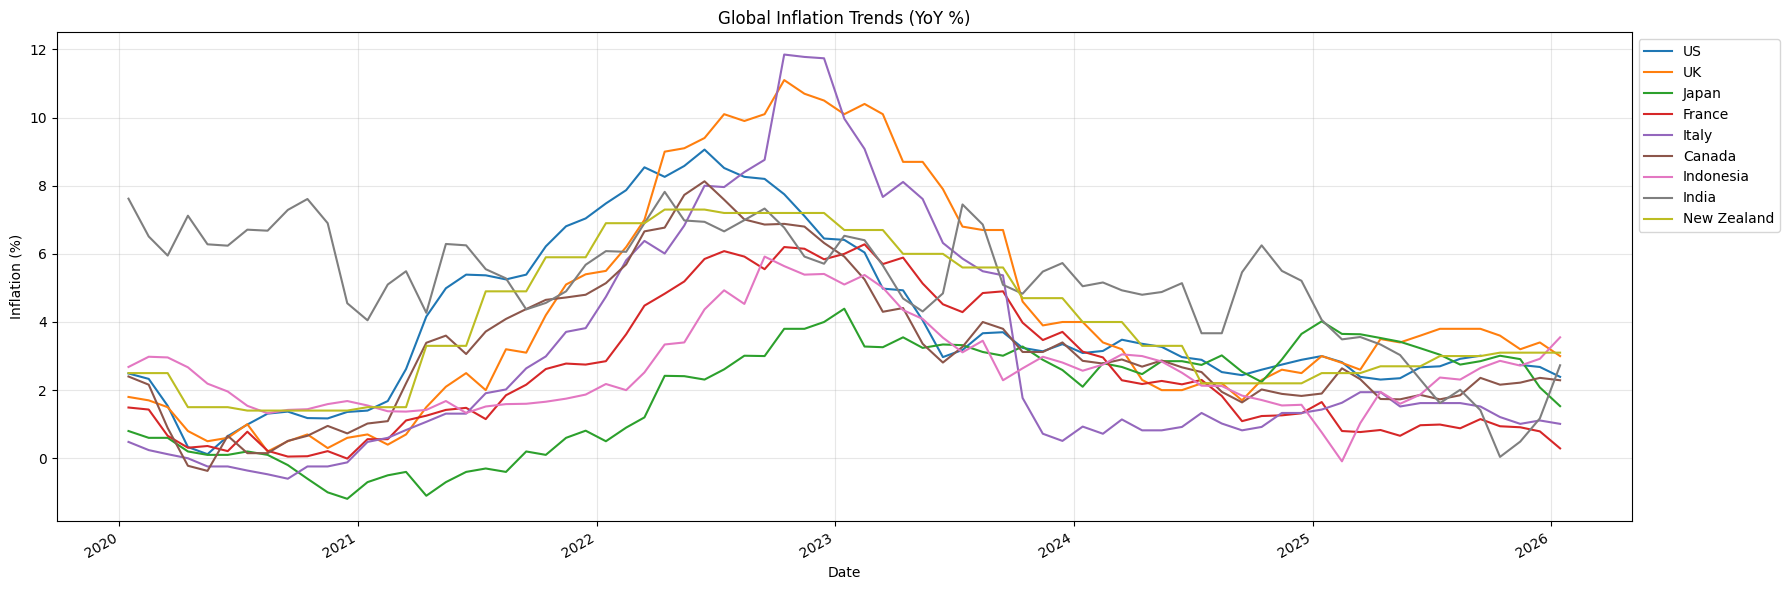

In [5]:
# Step 5: Visualizing Trends with Line Charts
df.plot(figsize=(18, 6))

plt.title("Global Inflation Trends (YoY %)")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")

plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Step 6: Reusable Heatmap Functions

# Step 6.1: Prepare Heatmap Data
def prepare_heatmap_data(df, freq="bi-monthly"):
    heatmap_df = df.T.copy()

    # convert datetime
    heatmap_df.columns = pd.to_datetime(heatmap_df.columns)

    if freq == "reduced":
        heatmap_df = heatmap_df.iloc[:, ::2]  # every 4 months

    # format date
    heatmap_df.columns = heatmap_df.columns.strftime("%Y-%m")

    return heatmap_df

# Step 6.2: Plot Heatmap
def plot_inflation_heatmap(df, name):
    plt.figure(figsize=(16, 6))
    
    sns.heatmap(
        df,
        cmap="coolwarm",
        linewidths=0.1,
        cbar_kws={"label": "Inflation (%)"}
    )
    
    plt.title(name)
    plt.xlabel("Time")
    plt.ylabel("Country")
    
    plt.tight_layout()
    plt.show()

In [7]:
# Step 6.3: Bi-Monthly vs Reduced Views

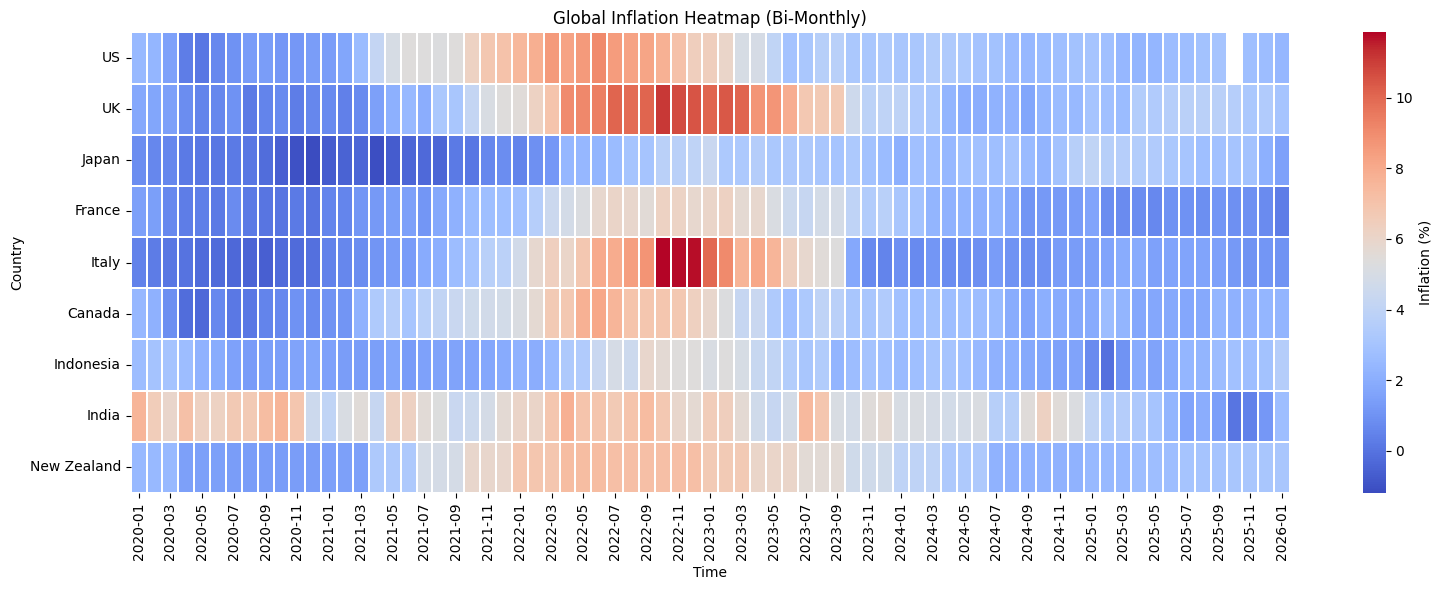

In [8]:
# monthly
hm_monthly = prepare_heatmap_data(df, freq="bi-monthly")
plot_inflation_heatmap(hm_monthly, "Global Inflation Heatmap (Bi-Monthly)")

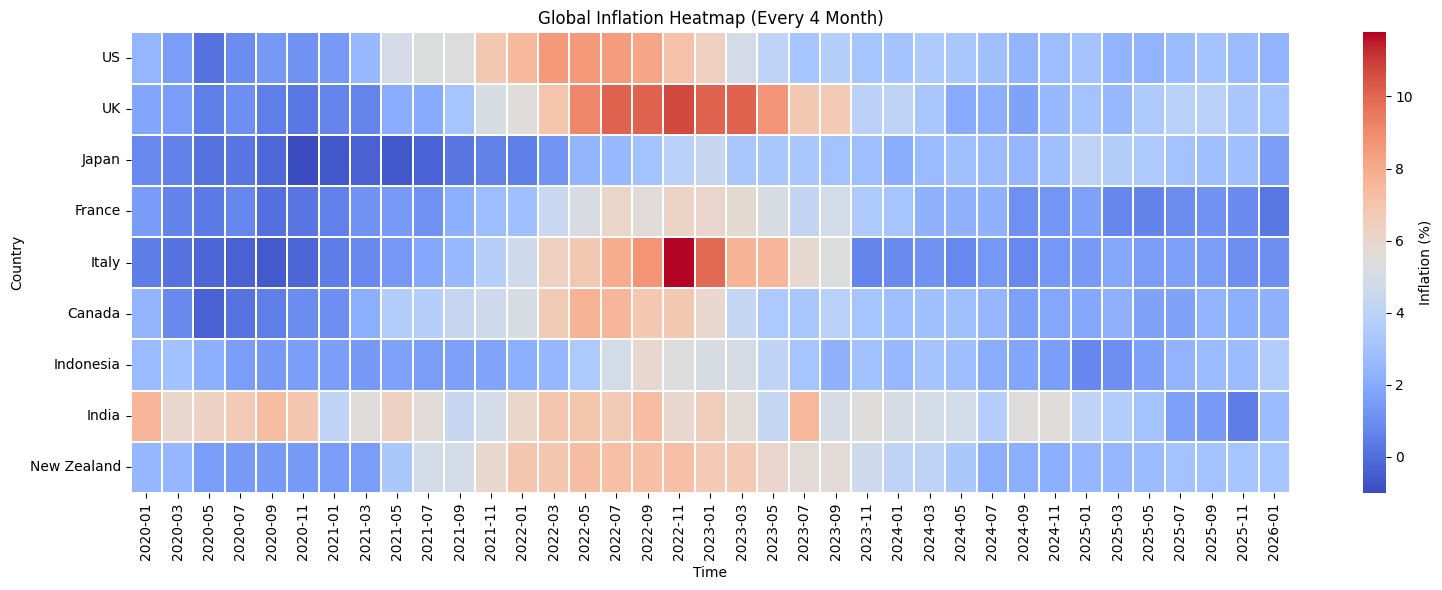

In [9]:
# quarterly
hm_quarterly = prepare_heatmap_data(df, freq="reduced")
plot_inflation_heatmap(hm_quarterly, "Global Inflation Heatmap (Every 4 Month)")